# Module 1: Data Loading and Augmentation Using PyTorch

This notebook completes the tasks required for PyTorch-based data loading and augmentation.
It builds a custom transformation pipeline, loads the dataset with ImageFolder, and displays a batch of augmented samples.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

base_dir = './images_dataSAT'
if not os.path.exists(base_dir):
    alt_dir = os.path.join('.', 'AI Capstone DL Projects', 'CNN Model Development', 'images_dataSAT')
    if os.path.exists(alt_dir):
        base_dir = alt_dir

print('Dataset directory:', base_dir)

dir_non_agri = os.path.join(base_dir, 'class_0_non_agri')
dir_agri = os.path.join(base_dir, 'class_1_agri')
print('Non-agri folder exists:', os.path.exists(dir_non_agri))
print('Agri folder exists:', os.path.exists(dir_agri))

c:\Users\Furqan Khan\AppData\Local\miniconda3\envs\agent_env2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset directory: .\AI Capstone DL Projects\CNN Model Development\images_dataSAT
Non-agri folder exists: True
Agri folder exists: True


## Task 1: Create the custom transformation pipeline

This pipeline resizes images to 64x64, randomly flips horizontally with probability 0.5, vertically with probability 0.2, and rotates by 45 degrees.

In [2]:
custom_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(45),
])

print(custom_transform)

Compose(
    Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.2)
    RandomRotation(degrees=[-45.0, 45.0], interpolation=nearest, expand=False, fill=0)
)


## Task 2: Load the dataset using ImageFolder

We create imagefolder_dataset with the custom transform.

In [3]:
imagefolder_dataset = datasets.ImageFolder(root=base_dir, transform=custom_transform)
print('Dataset classes:', imagefolder_dataset.classes)
print('Dataset class_to_idx:', imagefolder_dataset.class_to_idx)

Dataset classes: ['class_0_non_agri', 'class_1_agri']
Dataset class_to_idx: {'class_0_non_agri': 0, 'class_1_agri': 1}


## Task 3: Print the dataset class name and index

This displays each folder name and the class index assigned by ImageFolder.

In [4]:
for class_name, class_index in imagefolder_dataset.class_to_idx.items():
    print(f'Class name: {class_name}, Class index: {class_index}')

Class name: class_0_non_agri, Class index: 0
Class name: class_1_agri, Class index: 1


## Task 4: Retrieve a batch from the data loader

We create a DataLoader and print the image and label tensor shapes.

In [6]:
imagefolder_loader = DataLoader(imagefolder_dataset, batch_size=8, shuffle=True)
if not any(isinstance(t, transforms.ToTensor) for t in custom_transform.transforms):
    custom_transform.transforms.append(transforms.ToTensor())

images, labels = next(iter(imagefolder_loader))

print('Images shape:', images.shape)
print('Labels shape:', labels.shape)
print('Sample labels:', labels[:10].tolist())

Images shape: torch.Size([8, 3, 64, 64])
Labels shape: torch.Size([8])
Sample labels: [1, 0, 1, 1, 1, 0, 1, 1]


## Task 5: Display the images in the custom loader batch

The next cell shows the first 8 augmented images from the batch.

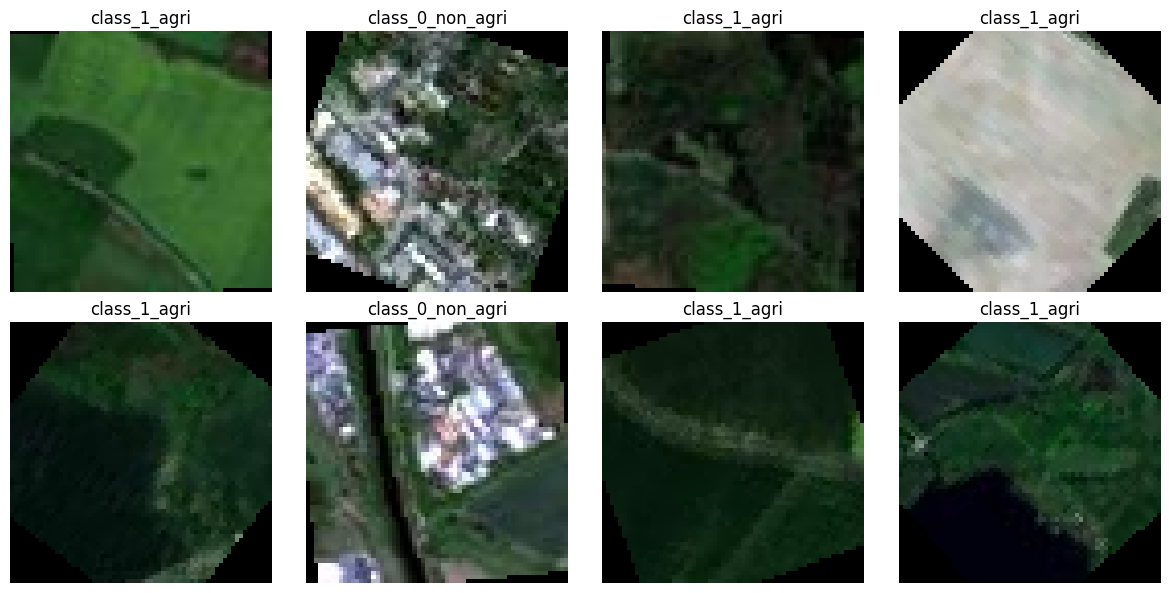

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, image, label in zip(axes.flat, images, labels):
    image = image.permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.axis('off')
    class_name = imagefolder_dataset.classes[label.item()]
    ax.set_title(class_name)

plt.tight_layout()
plt.show()